In [49]:
# !pip install -U numpy pandas scipy scikit-learn statsmodels matplotlib joblib doubleml

In [50]:
import os
import json
import math
import warnings
from dataclasses import dataclass, asdict
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import brentq
from sklearn.base import clone
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

RANDOM_STATE = 20260321
np.random.seed(RANDOM_STATE)

In [51]:
from doubleml.datasets import fetch_401K

df_401k = fetch_401K(return_type="DataFrame")

print("shape:", df_401k.shape)
print("columns:", df_401k.columns.tolist())
df_401k.head()

shape: (9915, 14)
columns: ['nifa', 'net_tfa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn', 'e401', 'p401', 'pira', 'hown']


,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
0,0.0,0.0,4500.0,47,6765.0,2,8,0,0,0,0,0,0,1
1,6215.0,1015.0,22390.0,36,28452.0,1,16,0,0,0,0,0,0,1
2,0.0,-2000.0,-2000.0,37,3300.0,6,12,1,0,0,0,0,0,0
3,15000.0,15000.0,155000.0,58,52590.0,2,16,0,1,1,0,0,0,1
4,0.0,0.0,58000.0,32,21804.0,1,11,0,0,0,0,0,0,1


In [52]:
Y_COL = "net_tfa"
D_COL = "e401"
X_COLS = ["age", "inc", "educ", "fsize", "marr", "twoearn", "db", "pira", "hown"]

df = df_401k[[Y_COL, D_COL] + X_COLS].copy().dropna().reset_index(drop=True)

print("n =", len(df))
display(df.describe().T)

n = 9915


,count,mean,std,min,25%,50%,75%,max
net_tfa,9915.0,18051.533203,63522.500000,-502302.0,-500.0,1499.0,16524.5,1536798.0
e401,9915.0,0.371357,0.483192,0.0,0.0,0.0,1.0,1.0
age,9915.0,41.060212,10.344505,25.0,32.0,40.0,48.0,64.0
inc,9915.0,37200.621094,24774.289062,-2652.0,19413.0,31476.0,48583.5,242124.0
educ,9915.0,13.206253,2.810382,1.0,12.0,12.0,16.0,18.0
fsize,9915.0,2.865860,1.538937,1.0,2.0,3.0,4.0,13.0
marr,9915.0,0.604841,0.488909,0.0,0.0,1.0,1.0,1.0
twoearn,9915.0,0.380837,0.485617,0.0,0.0,0.0,1.0,1.0
db,9915.0,0.271004,0.444500,0.0,0.0,0.0,1.0,1.0
pira,9915.0,0.242158,0.428411,0.0,0.0,0.0,0.0,1.0


In [53]:
def winsorize_series(s: pd.Series, lower_q: float, upper_q: float) -> pd.Series:
    lo, hi = s.quantile(lower_q), s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)

def winsorize_dataframe(df_in: pd.DataFrame, cols: List[str], lower_q: float, upper_q: float) -> pd.DataFrame:
    out = df_in.copy()
    for c in cols:
        out[c] = winsorize_series(out[c], lower_q, upper_q)
    return out

def make_y_learner():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LassoCV(cv=5, random_state=RANDOM_STATE, n_alphas=50, max_iter=20000))
    ])

def make_d_learner():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegressionCV(
            cv=5,
            penalty="l2",
            solver="lbfgs",
            random_state=RANDOM_STATE,
            max_iter=5000,
            scoring="neg_log_loss"
        ))
    ])

def top_share(values: np.ndarray, alpha: float) -> float:
    vals = np.abs(np.asarray(values))
    total = vals.sum()
    if total <= 0:
        return np.nan
    k = max(1, int(np.floor(alpha * len(vals))))
    topk = np.sort(vals)[::-1][:k].sum()
    return float(topk / total)

def score_ess(values: np.ndarray) -> float:
    vals = np.asarray(values)
    num = np.abs(vals).sum() ** 2
    den = np.square(vals).sum()
    if den <= 0:
        return np.nan
    return float(num / den)

def clipped(z: np.ndarray, tau: float) -> np.ndarray:
    return np.sign(z) * np.minimum(np.abs(z), tau)

def normal_ci(theta: float, se: float, alpha: float = 0.05) -> Tuple[float, float]:
    z = 1.959963984540054
    return theta - z * se, theta + z * se

def weighted_quantile(x: np.ndarray, q: float) -> float:
    return float(np.quantile(np.asarray(x), q))

def compact_table(df_in: pd.DataFrame, cols: List[str], digits: int = 4) -> str:
    tmp = df_in[cols].copy()
    for c in tmp.columns:
        if pd.api.types.is_numeric_dtype(tmp[c]):
            if "lambda" in c.lower():
                tmp[c] = tmp[c].map(lambda x: f"{float(x):.1e}")
            else:
                tmp[c] = tmp[c].map(lambda x: round(float(x), digits))
    return tmp.to_markdown(index=False)

In [54]:
def crossfit_nuisance(
    df_in: pd.DataFrame,
    y_col: str,
    d_col: str,
    x_cols: List[str],
    n_splits: int = 5,
    random_state: int = RANDOM_STATE,
):
    y = df_in[y_col].to_numpy()
    d = df_in[d_col].to_numpy()
    X = df_in[x_cols].to_numpy()

    g_hat = np.zeros(len(df_in), dtype=float)
    m_hat = np.zeros(len(df_in), dtype=float)

    if set(np.unique(d)).issubset({0, 1}):
        splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        split_iter = splitter.split(X, d)
    else:
        splitter = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        split_iter = splitter.split(X)

    for train_idx, test_idx in split_iter:
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr = y[train_idx]
        d_tr = d[train_idx]

        g_model = clone(make_y_learner())
        m_model = clone(make_d_learner())

        g_model.fit(X_tr, y_tr)
        m_model.fit(X_tr, d_tr)

        g_hat[test_idx] = g_model.predict(X_te)
        m_hat[test_idx] = m_model.predict_proba(X_te)[:, 1]

    U_hat = y - g_hat
    V_hat = d - m_hat

    out = df_in.copy()
    out["_g_hat"] = g_hat
    out["_m_hat"] = m_hat
    out["_U_hat"] = U_hat
    out["_V_hat"] = V_hat
    return out

In [55]:
@dataclass
class DMLResult:
    estimator: str
    theta: float
    se: float
    ci_low: float
    ci_high: float
    J_hat: float
    score_sd: float
    top1_share: float
    top05_share: float
    ess: float
    tau: Optional[float] = None
    q: Optional[float] = None
    bias_proxy: Optional[float] = None
    notes: Optional[str] = None

def dml_standard_from_residuals(U_hat: np.ndarray, V_hat: np.ndarray, estimator_name: str = "standard_dml") -> DMLResult:
    theta = float(np.mean(V_hat * U_hat) / np.mean(V_hat ** 2))
    psi = V_hat * (U_hat - theta * V_hat)

    J_hat = -float(np.mean(V_hat ** 2))
    infl = -psi / J_hat
    se = float(np.std(infl, ddof=1) / np.sqrt(len(infl)))
    ci_low, ci_high = normal_ci(theta, se)

    return DMLResult(
        estimator=estimator_name,
        theta=theta,
        se=se,
        ci_low=ci_low,
        ci_high=ci_high,
        J_hat=J_hat,
        score_sd=float(np.std(psi, ddof=1)),
        top1_share=top_share(psi, 0.01),
        top05_share=top_share(psi, 0.005),
        ess=score_ess(psi),
        tau=None,
        q=None,
        bias_proxy=None,
        notes="Standard orthogonal-score DML."
    )

def clipped_moment(theta: float, U_hat: np.ndarray, V_hat: np.ndarray, tau: float) -> float:
    psi = V_hat * (U_hat - theta * V_hat)
    return float(np.mean(clipped(psi, tau)))

def solve_clipped_theta(U_hat: np.ndarray, V_hat: np.ndarray, tau: float) -> float:
    theta_std = float(np.mean(V_hat * U_hat) / np.mean(V_hat ** 2))
    grid = np.linspace(theta_std - 50000, theta_std + 50000, 401)
    vals = np.array([clipped_moment(t, U_hat, V_hat, tau) for t in grid])

    sign_change_idx = None
    for i in range(len(grid) - 1):
        if vals[i] == 0:
            return float(grid[i])
        if vals[i] * vals[i + 1] < 0:
            sign_change_idx = i
            break

    if sign_change_idx is not None:
        a, b = grid[sign_change_idx], grid[sign_change_idx + 1]
        return float(brentq(lambda t: clipped_moment(t, U_hat, V_hat, tau), a, b, maxiter=1000))

    idx = int(np.argmin(np.abs(vals)))
    return float(grid[idx])

def numerical_jacobian(theta: float, U_hat: np.ndarray, V_hat: np.ndarray, tau: float, h: float = 1e-4) -> float:
    f_plus = clipped_moment(theta + h, U_hat, V_hat, tau)
    f_minus = clipped_moment(theta - h, U_hat, V_hat, tau)
    return float((f_plus - f_minus) / (2 * h))

def dml_clipped_from_residuals(U_hat: np.ndarray, V_hat: np.ndarray, q: float, theta_prelim: Optional[float] = None) -> DMLResult:
    if theta_prelim is None:
        theta_prelim = float(np.mean(V_hat * U_hat) / np.mean(V_hat ** 2))

    psi_prelim = V_hat * (U_hat - theta_prelim * V_hat)
    tau = weighted_quantile(np.abs(psi_prelim), q)

    theta = solve_clipped_theta(U_hat, V_hat, tau)
    psi = V_hat * (U_hat - theta * V_hat)
    psi_clip = clipped(psi, tau)

    J_hat = numerical_jacobian(theta, U_hat, V_hat, tau)
    if abs(J_hat) < 1e-8:
        J_hat = -float(np.mean(V_hat ** 2))

    infl = -psi_clip / J_hat
    se = float(np.std(infl, ddof=1) / np.sqrt(len(infl)))
    ci_low, ci_high = normal_ci(theta, se)

    bias_proxy = float(np.mean(np.maximum(np.abs(psi_prelim) - tau, 0.0)))

    return DMLResult(
        estimator=f"score_clipped_dml_q{q}",
        theta=theta,
        se=se,
        ci_low=ci_low,
        ci_high=ci_high,
        J_hat=J_hat,
        score_sd=float(np.std(psi_clip, ddof=1)),
        top1_share=top_share(psi_clip, 0.01),
        top05_share=top_share(psi_clip, 0.005),
        ess=score_ess(psi_clip),
        tau=float(tau),
        q=float(q),
        bias_proxy=bias_proxy,
        notes="Clipped-score DML using empirical preliminary-score quantile."
    )

In [56]:
def multiplier_bootstrap_ci(
    theta_hat: float,
    psi_values: np.ndarray,
    J_hat: float,
    B: int = 999,
    alpha: float = 0.05,
    random_state: int = RANDOM_STATE
):
    rng = np.random.default_rng(random_state)
    n = len(psi_values)
    draws = np.empty(B)

    for b in range(B):
        xi = rng.standard_normal(n)
        boot_shift = -np.mean(xi * psi_values) / J_hat
        draws[b] = theta_hat + boot_shift

    low = float(np.quantile(draws, alpha / 2))
    high = float(np.quantile(draws, 1 - alpha / 2))
    return low, high, draws

def self_normalized_ci(theta_hat: float, psi_values: np.ndarray, J_hat: float, alpha: float = 0.05):
    n = len(psi_values)
    infl = -psi_values / J_hat
    se_sn = float(np.sqrt(np.mean((infl - infl.mean()) ** 2) / n))
    low, high = normal_ci(theta_hat, se_sn, alpha=alpha)
    return low, high, se_sn

In [57]:
def select_q_concentration_constrained(
    clipped_path: pd.DataFrame,
    concentration_col: str = "top1_share",
    q_col: str = "q",
    kappa: float = 0.05
):
    tmp = clipped_path.copy().sort_values(q_col)
    feasible = tmp[tmp[concentration_col] <= kappa].copy()

    if len(feasible) == 0:
        best = tmp.sort_values(concentration_col).iloc[0]
    else:
        best = feasible.sort_values(q_col, ascending=False).iloc[0]

    return {
        "selected_q": float(best[q_col]),
        "selected_top1_share": float(best[concentration_col]),
        "selected_theta": float(best["theta"]),
        "selected_se": float(best["se"]),
        "selected_ess": float(best["ess"]),
        "selected_bias_proxy": float(best["bias_proxy"]),
        "selector": "concentration_constrained"
    }

def select_q_risk_proxy(
    clipped_path: pd.DataFrame,
    lambda_bias: float = 1e-8,
    se_col: str = "se",
    bias_proxy_col: str = "bias_proxy",
    q_col: str = "q"
):
    tmp = clipped_path.copy()
    tmp["risk_proxy"] = (tmp[se_col] ** 2) + lambda_bias * (tmp[bias_proxy_col] ** 2)
    best = tmp.sort_values("risk_proxy").iloc[0]

    return {
        "selected_q": float(best[q_col]),
        "risk_proxy": float(best["risk_proxy"]),
        "selected_theta": float(best["theta"]),
        "selected_se": float(best["se"]),
        "selected_bias_proxy": float(best[bias_proxy_col]),
        "selected_top1_share": float(best["top1_share"]),
        "selected_ess": float(best["ess"]),
        "selector": "risk_proxy",
        "lambda_bias": float(lambda_bias)
    }

In [58]:
def run_empirical_pipeline(
    df_in: pd.DataFrame,
    y_col: str,
    d_col: str,
    x_cols: List[str],
    clip_grid: List[float] = [0.95, 0.97, 0.99, 0.995, 0.999],
    winsor_q: Tuple[float, float] = (0.01, 0.99),
):
    cf_std = crossfit_nuisance(df_in, y_col, d_col, x_cols)
    std_res = dml_standard_from_residuals(cf_std["_U_hat"].to_numpy(), cf_std["_V_hat"].to_numpy(), "standard_dml")

    df_yw = df_in.copy()
    df_yw[y_col] = winsorize_series(df_yw[y_col], winsor_q[0], winsor_q[1])
    cf_yw = crossfit_nuisance(df_yw, y_col, d_col, x_cols)
    yw_res = dml_standard_from_residuals(cf_yw["_U_hat"].to_numpy(), cf_yw["_V_hat"].to_numpy(), "outcome_winsorized_dml")

    df_xw = winsorize_dataframe(df_in, x_cols, winsor_q[0], winsor_q[1])
    cf_xw = crossfit_nuisance(df_xw, y_col, d_col, x_cols)
    xw_res = dml_standard_from_residuals(cf_xw["_U_hat"].to_numpy(), cf_xw["_V_hat"].to_numpy(), "covariate_winsorized_dml")

    U_std = cf_std["_U_hat"].to_numpy()
    V_std = cf_std["_V_hat"].to_numpy()
    clip_results = []
    for q in clip_grid:
        clip_results.append(dml_clipped_from_residuals(U_std, V_std, q=q, theta_prelim=std_res.theta))

    clip_df = pd.DataFrame([asdict(r) for r in clip_results])
    best_idx = clip_df["top1_share"].idxmin()
    best_clip = clip_results[int(best_idx)]

    psi_std = V_std * (U_std - std_res.theta * V_std)
    std_mb_low, std_mb_high, _ = multiplier_bootstrap_ci(std_res.theta, psi_std, std_res.J_hat)
    std_sn_low, std_sn_high, std_sn_se = self_normalized_ci(std_res.theta, psi_std, std_res.J_hat)

    psi_best = V_std * (U_std - best_clip.theta * V_std)
    psi_best_clip = clipped(psi_best, best_clip.tau)
    best_mb_low, best_mb_high, _ = multiplier_bootstrap_ci(best_clip.theta, psi_best_clip, best_clip.J_hat)
    best_sn_low, best_sn_high, best_sn_se = self_normalized_ci(best_clip.theta, psi_best_clip, best_clip.J_hat)

    extra_inference = pd.DataFrame([
        {
            "estimator": "standard_dml",
            "theta": std_res.theta,
            "wald_low": std_res.ci_low,
            "wald_high": std_res.ci_high,
            "multiplier_low": std_mb_low,
            "multiplier_high": std_mb_high,
            "selfnorm_low": std_sn_low,
            "selfnorm_high": std_sn_high,
            "selfnorm_se": std_sn_se,
        },
        {
            "estimator": best_clip.estimator,
            "theta": best_clip.theta,
            "wald_low": best_clip.ci_low,
            "wald_high": best_clip.ci_high,
            "multiplier_low": best_mb_low,
            "multiplier_high": best_mb_high,
            "selfnorm_low": best_sn_low,
            "selfnorm_high": best_sn_high,
            "selfnorm_se": best_sn_se,
        }
    ])

    all_main = pd.DataFrame([asdict(std_res), asdict(yw_res), asdict(xw_res)] + [asdict(r) for r in clip_results])

    return {
        "crossfit_standard": cf_std,
        "main_results": all_main,
        "clipped_path": clip_df,
        "extra_inference": extra_inference,
        "best_clipped_result": asdict(best_clip),
    }

In [59]:
empirical_out = run_empirical_pipeline(
    df_in=df,
    y_col=Y_COL,
    d_col=D_COL,
    x_cols=X_COLS,
    clip_grid=[0.95, 0.97, 0.99, 0.995, 0.999],
    winsor_q=(0.01, 0.99),
)

main_results = empirical_out["main_results"]
clipped_path = empirical_out["clipped_path"]
extra_inference = empirical_out["extra_inference"]

print("=== Main Results ===")
display(main_results[[
    "estimator", "theta", "se", "ci_low", "ci_high",
    "top1_share", "top05_share", "ess", "tau", "q", "bias_proxy"
]])

print("\n=== Robust Inference Comparison ===")
display(extra_inference)

=== Main Results ===


,estimator,theta,se,ci_low,ci_high,top1_share,top05_share,ess,tau,q,bias_proxy
0,standard_dml,6084.305415,1459.195649,3224.334497,8944.276333,0.185754,0.138978,1117.002482,NaN,NaN,NaN
1,outcome_winsorized_dml,7218.351961,711.769153,5823.310056,8613.393866,0.110069,0.062600,2924.789218,NaN,NaN,NaN
2,covariate_winsorized_dml,6455.943626,1412.681972,3687.137839,9224.749412,0.186639,0.140012,1171.108927,NaN,NaN,NaN
3,score_clipped_dml_q0.95,6038.622275,628.355245,4807.068626,7270.175924,0.039762,0.019680,4591.478090,30938.083929,0.950,2050.720891
4,score_clipped_dml_q0.97,6567.361270,656.666378,5280.318818,7854.403721,0.048893,0.024200,4237.536129,39729.749506,0.970,1713.375160
5,score_clipped_dml_q0.99,7458.188905,762.645164,5963.431851,8952.945959,0.086607,0.042866,3391.677267,76079.375255,0.990,1064.544109
6,score_clipped_dml_q0.995,7592.381792,829.456122,5966.677666,9218.085918,0.112115,0.061364,2977.255231,112067.515528,0.995,811.201493
7,score_clipped_dml_q0.999,7070.442874,1057.248459,4998.273972,9142.611777,0.155449,0.107083,1993.013066,319992.593261,0.999,349.876931



=== Robust Inference Comparison ===


,estimator,theta,wald_low,wald_high,multiplier_low,multiplier_high,selfnorm_low,selfnorm_high,selfnorm_se
0,standard_dml,6084.305415,3224.334497,8944.276333,3177.381611,9099.866256,3224.478725,8944.132105,1459.122062
1,score_clipped_dml_q0.95,6038.622275,4807.068626,7270.175924,4762.581930,7286.211572,4807.130733,7270.113817,628.323557


In [60]:
cc_selector_result = select_q_concentration_constrained(
    clipped_path=clipped_path,
    concentration_col="top1_share",
    q_col="q",
    kappa=0.05
)

rp_selector_result = select_q_risk_proxy(
    clipped_path=clipped_path,
    lambda_bias=1e-8
)

selector_results_df = pd.DataFrame([cc_selector_result, rp_selector_result])
display(selector_results_df)

,selected_q,selected_top1_share,selected_theta,selected_se,selected_ess,selected_bias_proxy,selector,risk_proxy,lambda_bias
0,0.97,0.048893,6567.361270,656.666378,4237.536129,1713.375160,concentration_constrained,NaN,NaN
1,0.95,0.039762,6038.622275,628.355245,4591.478090,2050.720891,risk_proxy,394830.355407,1.000000e-08


In [61]:
selector_table = pd.DataFrame([
    {
        "Selector": "Concentration-constrained",
        "Selected q": cc_selector_result["selected_q"],
        "Theta": cc_selector_result["selected_theta"],
        "SE": cc_selector_result["selected_se"],
        "Top-1% Share": cc_selector_result["selected_top1_share"],
        "ESS": cc_selector_result["selected_ess"],
        "Bias Proxy": cc_selector_result["selected_bias_proxy"],
    },
    {
        "Selector": "Risk-proxy",
        "Selected q": rp_selector_result["selected_q"],
        "Theta": rp_selector_result["selected_theta"],
        "SE": rp_selector_result["selected_se"],
        "Top-1% Share": rp_selector_result["selected_top1_share"],
        "ESS": rp_selector_result["selected_ess"],
        "Bias Proxy": rp_selector_result["selected_bias_proxy"],
    },
])

display(selector_table)
print(selector_table.to_latex(index=False, escape=False))

,Selector,Selected q,Theta,SE,Top-1% Share,ESS,Bias Proxy
0,Concentration-constrained,0.97,6567.361270,656.666378,0.048893,4237.536129,1713.375160
1,Risk-proxy,0.95,6038.622275,628.355245,0.039762,4591.478090,2050.720891


\begin{tabular}{lrrrrrr}
\toprule
Selector & Selected q & Theta & SE & Top-1% Share & ESS & Bias Proxy \\
\midrule
Concentration-constrained & 0.970000 & 6567.361270 & 656.666378 & 0.048893 & 4237.536129 & 1713.375160 \\
Risk-proxy & 0.950000 & 6038.622275 & 628.355245 & 0.039762 & 4591.478090 & 2050.720891 \\
\bottomrule
\end{tabular}



In [62]:
lambda_grid = [1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
lambda_sensitivity = []

for lam in lambda_grid:
    out = select_q_risk_proxy(clipped_path, lambda_bias=lam)
    lambda_sensitivity.append(out)

lambda_sensitivity_df = pd.DataFrame(lambda_sensitivity)
display(lambda_sensitivity_df)

,selected_q,risk_proxy,selected_theta,selected_se,selected_bias_proxy,selected_top1_share,selected_ess,selector,lambda_bias
0,0.95,394830.313773,6038.622275,628.355245,2050.720891,0.039762,4591.47809,risk_proxy,1.000000e-10
1,0.95,394830.317557,6038.622275,628.355245,2050.720891,0.039762,4591.47809,risk_proxy,1.000000e-09
2,0.95,394830.355407,6038.622275,628.355245,2050.720891,0.039762,4591.47809,risk_proxy,1.000000e-08
3,0.95,394830.733898,6038.622275,628.355245,2050.720891,0.039762,4591.47809,risk_proxy,1.000000e-07
4,0.95,394834.518808,6038.622275,628.355245,2050.720891,0.039762,4591.47809,risk_proxy,1.000000e-06
5,0.95,394872.367914,6038.622275,628.355245,2050.720891,0.039762,4591.47809,risk_proxy,1.000000e-05


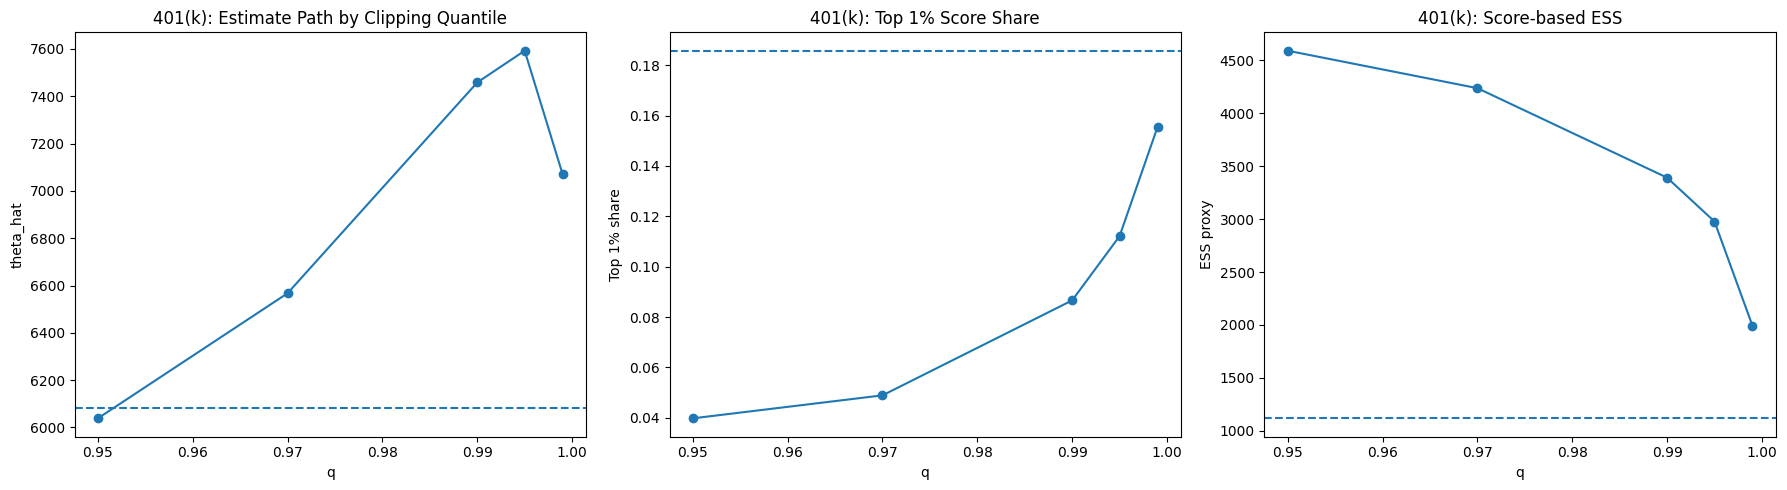

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(clipped_path["q"], clipped_path["theta"], marker="o")
axes[0].axhline(
    main_results.loc[main_results["estimator"] == "standard_dml", "theta"].iloc[0],
    linestyle="--"
)
axes[0].set_title("401(k): Estimate Path by Clipping Quantile")
axes[0].set_xlabel("q")
axes[0].set_ylabel("theta_hat")

axes[1].plot(clipped_path["q"], clipped_path["top1_share"], marker="o")
axes[1].axhline(
    main_results.loc[main_results["estimator"] == "standard_dml", "top1_share"].iloc[0],
    linestyle="--"
)
axes[1].set_title("401(k): Top 1% Score Share")
axes[1].set_xlabel("q")
axes[1].set_ylabel("Top 1% share")

axes[2].plot(clipped_path["q"], clipped_path["ess"], marker="o")
axes[2].axhline(
    main_results.loc[main_results["estimator"] == "standard_dml", "ess"].iloc[0],
    linestyle="--"
)
axes[2].set_title("401(k): Score-based ESS")
axes[2].set_xlabel("q")
axes[2].set_ylabel("ESS proxy")

plt.tight_layout()
plt.show()

In [64]:
threshold_path_table = clipped_path[[
    "q", "theta", "se", "ci_low", "ci_high",
    "top1_share", "top05_share", "ess", "bias_proxy"
]].copy()

threshold_path_table["95% CI"] = threshold_path_table.apply(
    lambda r: f"[{r['ci_low']:.2f}, {r['ci_high']:.2f}]",
    axis=1
)

threshold_path_table = threshold_path_table[[
    "q", "theta", "se", "95% CI", "top1_share", "top05_share", "ess", "bias_proxy"
]]

display(threshold_path_table)
print(threshold_path_table.to_latex(index=False, escape=False))

,q,theta,se,95% CI,top1_share,top05_share,ess,bias_proxy
0,0.950,6038.622275,628.355245,"[4807.07, 7270.18]",0.039762,0.019680,4591.478090,2050.720891
1,0.970,6567.361270,656.666378,"[5280.32, 7854.40]",0.048893,0.024200,4237.536129,1713.375160
2,0.990,7458.188905,762.645164,"[5963.43, 8952.95]",0.086607,0.042866,3391.677267,1064.544109
3,0.995,7592.381792,829.456122,"[5966.68, 9218.09]",0.112115,0.061364,2977.255231,811.201493
4,0.999,7070.442874,1057.248459,"[4998.27, 9142.61]",0.155449,0.107083,1993.013066,349.876931


\begin{tabular}{rrrlrrrr}
\toprule
q & theta & se & 95% CI & top1_share & top05_share & ess & bias_proxy \\
\midrule
0.950000 & 6038.622275 & 628.355245 & [4807.07, 7270.18] & 0.039762 & 0.019680 & 4591.478090 & 2050.720891 \\
0.970000 & 6567.361270 & 656.666378 & [5280.32, 7854.40] & 0.048893 & 0.024200 & 4237.536129 & 1713.375160 \\
0.990000 & 7458.188905 & 762.645164 & [5963.43, 8952.95] & 0.086607 & 0.042866 & 3391.677267 & 1064.544109 \\
0.995000 & 7592.381792 & 829.456122 & [5966.68, 9218.09] & 0.112115 & 0.061364 & 2977.255231 & 811.201493 \\
0.999000 & 7070.442874 & 1057.248459 & [4998.27, 9142.61] & 0.155449 & 0.107083 & 1993.013066 & 349.876931 \\
\bottomrule
\end{tabular}



In [65]:
def make_latex_table_401k(main_results: pd.DataFrame, best_estimator_name: Optional[str] = None):
    if best_estimator_name is None:
        clipped_only = main_results[main_results["estimator"].str.contains("score_clipped")]
        best_estimator_name = clipped_only.sort_values("top1_share").iloc[0]["estimator"]

    keep = main_results[main_results["estimator"].isin(["standard_dml", best_estimator_name])].copy()
    keep["95% CI"] = keep.apply(lambda r: f"[{r['ci_low']:.2f}, {r['ci_high']:.2f}]", axis=1)
    keep["Estimator"] = keep["estimator"].replace({
        "standard_dml": "Standard DML",
        best_estimator_name: f"Best clipped DML ({best_estimator_name.split('_q')[-1]})"
    })

    table_df = keep[["Estimator", "theta", "se", "95% CI", "top1_share", "top05_share", "ess"]].copy()
    table_df.columns = ["Estimator", "$\\hat\\theta$", "SE", "95\\% CI", "Top-1\\% Share", "Top-0.5\\% Share", "ESS Proxy"]
    return table_df

table_401k = make_latex_table_401k(main_results)
display(table_401k)

print(table_401k.to_latex(index=False, escape=False))

,Estimator,$\hat\theta$,SE,95\% CI,Top-1\% Share,Top-0.5\% Share,ESS Proxy
0,Standard DML,6084.305415,1459.195649,"[3224.33, 8944.28]",0.185754,0.138978,1117.002482
3,Best clipped DML (0.95),6038.622275,628.355245,"[4807.07, 7270.18]",0.039762,0.019680,4591.478090


\begin{tabular}{lrrlrrr}
\toprule
Estimator & $\hat\theta$ & SE & 95\% CI & Top-1\% Share & Top-0.5\% Share & ESS Proxy \\
\midrule
Standard DML & 6084.305415 & 1459.195649 & [3224.33, 8944.28] & 0.185754 & 0.138978 & 1117.002482 \\
Best clipped DML (0.95) & 6038.622275 & 628.355245 & [4807.07, 7270.18] & 0.039762 & 0.019680 & 4591.478090 \\
\bottomrule
\end{tabular}



In [66]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def draw_error(dist: str, n: int, rng: np.random.Generator):
    if dist == "normal":
        return rng.normal(size=n)
    elif dist == "t5":
        return rng.standard_t(df=5, size=n)
    elif dist == "t3":
        return rng.standard_t(df=3, size=n)
    else:
        raise ValueError(f"Unknown dist: {dist}")

def simulate_plr_data(
    n: int = 2000,
    p: int = 10,
    theta0: float = 0.5,
    tail: str = "normal",
    contamination: float = 0.0,
    weak_overlap: bool = False,
    nonlinear: bool = False,
    random_state: int = RANDOM_STATE,
):
    rng = np.random.default_rng(random_state)

    X = rng.normal(size=(n, p))
    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]

    if nonlinear:
        g0 = 0.8 * np.sin(x1) + 0.5 * (x2 ** 2) - 0.3 * x3
        m_latent = 0.8 * np.sin(x1) - 0.6 * x2 + 0.4 * x3 * x1
    else:
        g0 = 0.6 * x1 - 0.5 * x2 + 0.3 * x3
        m_latent = 0.7 * x1 - 0.5 * x2 + 0.2 * x3

    if weak_overlap:
        m_latent = 2.0 * m_latent

    pscore = sigmoid(m_latent)
    D = rng.binomial(1, pscore, size=n)

    U = draw_error(tail, n, rng)
    Y = theta0 * D + g0 + U

    if contamination > 0:
        idx = rng.choice(n, size=int(n * contamination), replace=False)
        Y[idx] = Y[idx] + rng.normal(loc=20.0, scale=5.0, size=len(idx))

    cols = [f"x{i+1}" for i in range(p)]
    df_sim = pd.DataFrame(X, columns=cols)
    df_sim["D"] = D
    df_sim["Y"] = Y
    return df_sim, cols

In [67]:
def run_single_sim(
    n: int,
    tail: str,
    contamination: float,
    weak_overlap: bool,
    nonlinear: bool,
    theta0: float = 0.5,
    clip_grid: List[float] = [0.95, 0.97, 0.99, 0.995, 0.999],
    seed: int = RANDOM_STATE,
):
    df_sim, x_cols = simulate_plr_data(
        n=n,
        tail=tail,
        contamination=contamination,
        weak_overlap=weak_overlap,
        nonlinear=nonlinear,
        theta0=theta0,
        random_state=seed,
    )

    out = run_empirical_pipeline(
        df_in=df_sim.rename(columns={"Y": "Y", "D": "D"}),
        y_col="Y",
        d_col="D",
        x_cols=x_cols,
        clip_grid=clip_grid,
        winsor_q=(0.01, 0.99),
    )

    res = out["main_results"].copy()
    res["true_theta"] = theta0
    res["bias"] = res["theta"] - theta0
    res["rmse_component"] = (res["theta"] - theta0) ** 2
    res["covered"] = ((res["ci_low"] <= theta0) & (theta0 <= res["ci_high"])).astype(int)

    res["tail"] = tail
    res["contamination"] = contamination
    res["weak_overlap"] = weak_overlap
    res["nonlinear"] = nonlinear
    return res

In [68]:
def run_simulation_grid(
    reps: int = 100,
    n: int = 2000,
    tails: List[str] = ["normal", "t5", "t3"],
    contaminations: List[float] = [0.0, 0.05],
    overlaps: List[bool] = [False, True],
    nonlinear_list: List[bool] = [False, True],
):
    all_rows = []

    rep_counter = 0
    total = reps * len(tails) * len(contaminations) * len(overlaps) * len(nonlinear_list)

    for tail in tails:
        for contamination in contaminations:
            for weak_overlap in overlaps:
                for nonlinear in nonlinear_list:
                    for r in range(reps):
                        rep_counter += 1
                        seed = RANDOM_STATE + 10000 * rep_counter
                        tmp = run_single_sim(
                            n=n,
                            tail=tail,
                            contamination=contamination,
                            weak_overlap=weak_overlap,
                            nonlinear=nonlinear,
                            seed=seed,
                        )
                        tmp["rep"] = r + 1
                        all_rows.append(tmp)

                        if rep_counter % 10 == 0:
                            print(f"progress: {rep_counter}/{total}")

    sim_df = pd.concat(all_rows, axis=0, ignore_index=True)
    return sim_df

In [69]:
sim_results = run_simulation_grid(
    reps=20,
    n=1500,
    tails=["normal", "t5", "t3"],
    contaminations=[0.0, 0.05],
    overlaps=[False, True],
    nonlinear_list=[False, True],
)

print(sim_results.shape)
sim_results.head()

progress: 10/480
progress: 20/480
progress: 30/480
progress: 40/480
progress: 50/480
progress: 60/480
progress: 70/480
progress: 80/480
progress: 90/480
progress: 100/480
progress: 110/480
progress: 120/480
progress: 130/480
progress: 140/480
progress: 150/480
progress: 160/480
progress: 170/480
progress: 180/480
progress: 190/480
progress: 200/480
progress: 210/480
progress: 220/480
progress: 230/480
progress: 240/480
progress: 250/480
progress: 260/480
progress: 270/480
progress: 280/480
progress: 290/480
progress: 300/480
progress: 310/480
progress: 320/480
progress: 330/480
progress: 340/480
progress: 350/480
progress: 360/480
progress: 370/480
progress: 380/480
progress: 390/480
progress: 400/480
progress: 410/480
progress: 420/480
progress: 430/480
progress: 440/480
progress: 450/480
progress: 460/480
progress: 470/480
progress: 480/480
(3840, 23)


,estimator,theta,se,ci_low,ci_high,J_hat,score_sd,top1_share,top05_share,ess,...,notes,true_theta,bias,rmse_component,covered,tail,contamination,weak_overlap,nonlinear,rep
0,standard_dml,0.438260,0.054641,0.331165,0.545355,-0.215548,0.456153,0.048827,0.025295,812.217786,...,Standard orthogonal-score DML.,0.5,-0.061740,0.003812,1,normal,0.0,False,False,1
1,outcome_winsorized_dml,0.433192,0.054210,0.326942,0.539442,-0.215548,0.452553,0.047931,0.024265,815.833419,...,Standard orthogonal-score DML.,0.5,-0.066808,0.004463,1,normal,0.0,False,False,1
2,covariate_winsorized_dml,0.440287,0.054771,0.332938,0.547637,-0.215484,0.457102,0.048794,0.025254,813.962615,...,Standard orthogonal-score DML.,0.5,-0.059713,0.003566,1,normal,0.0,False,False,1
3,score_clipped_dml_q0.95,0.450169,0.055232,0.341916,0.558422,-0.195423,0.418038,0.029659,0.013841,889.141656,...,Clipped-score DML using empirical preliminary-...,0.5,-0.049831,0.002483,1,normal,0.0,False,False,1
4,score_clipped_dml_q0.97,0.443825,0.055186,0.335663,0.551988,-0.202861,0.433584,0.034256,0.015986,859.871540,...,Clipped-score DML using empirical preliminary-...,0.5,-0.056175,0.003156,1,normal,0.0,False,False,1


In [70]:
summary_cols = ["bias", "rmse_component", "covered", "top1_share", "top05_share", "ess"]

sim_summary = (
    sim_results
    .groupby("estimator")[summary_cols]
    .agg({
        "bias": "mean",
        "rmse_component": lambda x: float(np.sqrt(np.mean(x))),
        "covered": "mean",
        "top1_share": "mean",
        "top05_share": "mean",
        "ess": "mean"
    })
    .reset_index()
    .rename(columns={
        "rmse_component": "rmse",
        "covered": "coverage"
    })
)

display(sim_summary.sort_values("rmse"))

,estimator,bias,rmse,coverage,top1_share,top05_share,ess
2,score_clipped_dml_q0.95,0.035567,0.117952,0.918750,0.038570,0.017999,752.228581
3,score_clipped_dml_q0.97,0.032638,0.155797,0.918750,0.056933,0.026569,622.050901
4,score_clipped_dml_q0.99,0.030732,0.199866,0.922917,0.091391,0.042649,519.549861
5,score_clipped_dml_q0.995,0.030369,0.208057,0.920833,0.105388,0.051536,495.600274
1,outcome_winsorized_dml,0.022131,0.209026,0.925000,0.110797,0.058960,489.861979
6,score_clipped_dml_q0.999,0.031595,0.214538,0.931250,0.115483,0.062225,471.651363
0,covariate_winsorized_dml,0.029348,0.216104,0.939583,0.118101,0.064966,460.841445
7,standard_dml,0.032418,0.216324,0.933333,0.118089,0.064991,460.601319


In [71]:
hostile = sim_results[
    (sim_results["tail"].isin(["t5", "t3"])) &
    (sim_results["contamination"] == 0.05) &
    (sim_results["weak_overlap"] == True) &
    (sim_results["nonlinear"] == True)
].copy()

hostile_summary = (
    hostile
    .groupby(["tail", "estimator"])[["bias", "rmse_component", "covered", "top1_share", "top05_share", "ess"]]
    .agg({
        "bias": "mean",
        "rmse_component": lambda x: float(np.sqrt(np.mean(x))),
        "covered": "mean",
        "top1_share": "mean",
        "top05_share": "mean",
        "ess": "mean"
    })
    .reset_index()
    .rename(columns={"rmse_component": "rmse", "covered": "coverage"})
    .sort_values(["tail", "rmse"])
)

display(hostile_summary)

,tail,estimator,bias,rmse,coverage,top1_share,top05_share,ess
2,t3,score_clipped_dml_q0.95,0.023503,0.117527,1.00,0.043810,0.020445,668.753685
3,t3,score_clipped_dml_q0.97,0.021305,0.175995,1.00,0.068206,0.031829,510.272633
4,t3,score_clipped_dml_q0.99,-0.003834,0.251243,0.95,0.122369,0.057105,349.600677
1,t3,outcome_winsorized_dml,-0.014911,0.266986,0.90,0.153132,0.082927,301.216521
5,t3,score_clipped_dml_q0.995,-0.007659,0.268617,0.90,0.140905,0.069116,320.909747
6,t3,score_clipped_dml_q0.999,-0.000631,0.271845,0.95,0.153964,0.083118,297.858749
7,t3,standard_dml,-0.000840,0.272200,0.95,0.155855,0.085171,293.709426
0,t3,covariate_winsorized_dml,-0.008499,0.275403,0.95,0.156667,0.085700,292.478581
10,t5,score_clipped_dml_q0.95,0.050778,0.159660,0.90,0.041556,0.019393,700.129909
11,t5,score_clipped_dml_q0.97,0.023238,0.201909,0.90,0.067922,0.031697,522.687781


In [72]:
def evaluate_selectors_from_sim(sim_results: pd.DataFrame):
    clip_only = sim_results[sim_results["estimator"].str.contains("score_clipped")].copy()
    group_cols = ["tail", "contamination", "weak_overlap", "nonlinear", "rep"]

    rows = []
    for keys, grp in clip_only.groupby(group_cols):
        grp = grp.sort_values("q").copy()

        oracle = grp.sort_values("rmse_component").iloc[0]

        feasible = grp[grp["top1_share"] <= 0.05]
        if len(feasible) > 0:
            cc = feasible.sort_values("q", ascending=False).iloc[0]
        else:
            cc = grp.sort_values("top1_share").iloc[0]

        tmp = grp.copy()
        tmp["risk_proxy"] = (tmp["se"] ** 2) + 1e-8 * (tmp["bias_proxy"] ** 2)
        rp = tmp.sort_values("risk_proxy").iloc[0]

        rows.append({
            **dict(zip(group_cols, keys)),
            "oracle_q": oracle["q"],
            "oracle_rmse": float(np.sqrt(oracle["rmse_component"])),
            "cc_q": cc["q"],
            "cc_rmse": float(np.sqrt(cc["rmse_component"])),
            "rp_q": rp["q"],
            "rp_rmse": float(np.sqrt(rp["rmse_component"])),
        })

    return pd.DataFrame(rows)

selector_eval = evaluate_selectors_from_sim(sim_results)
display(selector_eval.head())

selector_eval_summary = selector_eval[["oracle_rmse", "cc_rmse", "rp_rmse"]].mean().to_frame("mean").T
display(selector_eval_summary)

,tail,contamination,weak_overlap,nonlinear,rep,oracle_q,oracle_rmse,cc_q,cc_rmse,rp_q,rp_rmse
0,normal,0.0,False,False,1,0.950,0.049831,0.999,0.061640,0.995,0.061053
1,normal,0.0,False,False,2,0.999,0.040046,0.999,0.040046,0.995,0.040321
2,normal,0.0,False,False,3,0.950,0.000925,0.999,0.021065,0.999,0.021065
3,normal,0.0,False,False,4,0.970,0.038137,0.999,0.040642,0.990,0.039342
4,normal,0.0,False,False,5,0.950,0.047636,0.999,0.058363,0.999,0.058363


,oracle_rmse,cc_rmse,rp_rmse
mean,0.080011,0.090865,0.090535


In [73]:
selector_eval_latex = selector_eval_summary.reset_index(drop=True).copy()
selector_eval_latex.columns = ["Oracle RMSE", "CC Selector RMSE", "Risk-Proxy RMSE"]
display(selector_eval_latex)
print(selector_eval_latex.to_latex(index=False, escape=False))

,Oracle RMSE,CC Selector RMSE,Risk-Proxy RMSE
0,0.080011,0.090865,0.090535


\begin{tabular}{rrr}
\toprule
Oracle RMSE & CC Selector RMSE & Risk-Proxy RMSE \\
\midrule
0.080011 & 0.090865 & 0.090535 \\
\bottomrule
\end{tabular}



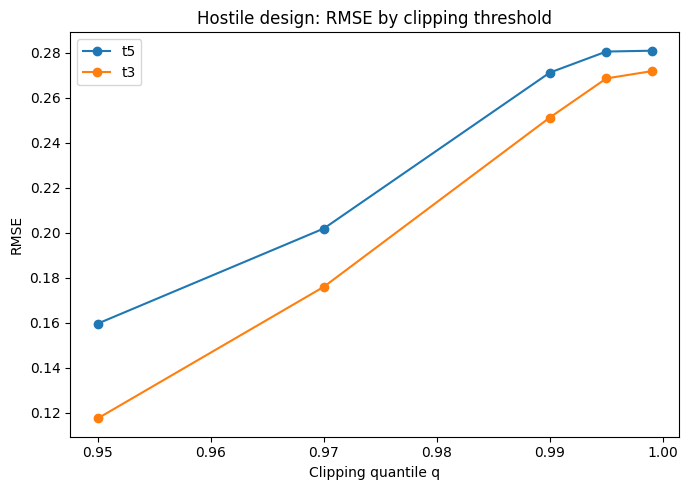

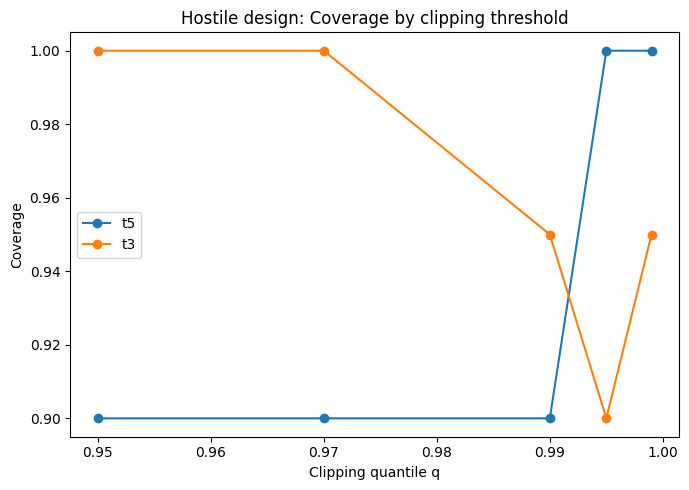

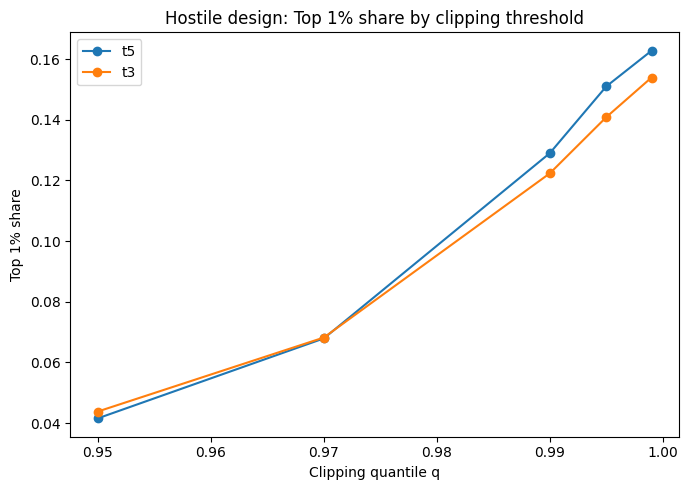

In [74]:
hostile_clip = hostile[hostile["estimator"].str.contains("score_clipped")].copy()
hostile_clip["q"] = hostile_clip["q"].astype(float)

for metric in ["rmse_component", "covered", "top1_share"]:
    plt.figure(figsize=(7, 5))
    for tail in ["t5", "t3"]:
        tmp = hostile_clip[hostile_clip["tail"] == tail].groupby("q")[metric].mean().reset_index()
        if metric == "rmse_component":
            y = np.sqrt(tmp[metric].to_numpy())
            ylabel = "RMSE"
        elif metric == "covered":
            y = tmp[metric].to_numpy()
            ylabel = "Coverage"
        else:
            y = tmp[metric].to_numpy()
            ylabel = "Top 1% share"

        plt.plot(tmp["q"], y, marker="o", label=tail)

    plt.xlabel("Clipping quantile q")
    plt.ylabel(ylabel)
    plt.title(f"Hostile design: {ylabel} by clipping threshold")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [75]:
os.makedirs("results_dml_heavytail", exist_ok=True)

main_results.to_csv("results_dml_heavytail/401k_main_results.csv", index=False)
clipped_path.to_csv("results_dml_heavytail/401k_clipped_path.csv", index=False)
extra_inference.to_csv("results_dml_heavytail/401k_inference_compare.csv", index=False)
selector_results_df.to_csv("results_dml_heavytail/401k_selector_results.csv", index=False)
lambda_sensitivity_df.to_csv("results_dml_heavytail/401k_lambda_sensitivity.csv", index=False)

sim_results.to_csv("results_dml_heavytail/simulation_raw_results.csv", index=False)
sim_summary.to_csv("results_dml_heavytail/simulation_summary.csv", index=False)
hostile_summary.to_csv("results_dml_heavytail/simulation_hostile_summary.csv", index=False)
selector_eval.to_csv("results_dml_heavytail/simulation_selector_eval.csv", index=False)
selector_eval_summary.to_csv("results_dml_heavytail/simulation_selector_eval_summary.csv", index=False)

bundle = {
    "dataset_info": {
        "dataset": "401K via doubleml.datasets.fetch_401K",
        "n_obs": int(len(df)),
        "y_col": Y_COL,
        "d_col": D_COL,
        "x_cols": X_COLS,
    },
    "best_clipped_result": empirical_out["best_clipped_result"],
    "main_results_records": main_results.to_dict(orient="records"),
    "inference_records": extra_inference.to_dict(orient="records"),
    "selector_results_records": selector_results_df.to_dict(orient="records"),
    "lambda_sensitivity_records": lambda_sensitivity_df.to_dict(orient="records"),
    "simulation_summary_records": sim_summary.to_dict(orient="records"),
    "hostile_summary_records": hostile_summary.to_dict(orient="records"),
    "selector_eval_summary_records": selector_eval_summary.reset_index(drop=True).to_dict(orient="records"),
}

with open("results_dml_heavytail/results_bundle.json", "w", encoding="utf-8") as f:
    json.dump(bundle, f, ensure_ascii=False, indent=2)

print("Saved to results_dml_heavytail/")

Saved to results_dml_heavytail/


In [76]:
best_clip_name = main_results[main_results["estimator"].str.contains("score_clipped")]\
    .sort_values("top1_share").iloc[0]["estimator"]

report = {
    "401k_main_results_markdown": compact_table(
        main_results[main_results["estimator"].isin(["standard_dml", "outcome_winsorized_dml", "covariate_winsorized_dml", best_clip_name])],
        ["estimator", "theta", "se", "ci_low", "ci_high", "top1_share", "top05_share", "ess", "q", "tau", "bias_proxy"]
    ),
    "401k_clipped_path_markdown": compact_table(
        clipped_path.sort_values("q"),
        ["estimator", "q", "theta", "se", "top1_share", "top05_share", "ess", "bias_proxy"]
    ),
    "inference_compare_markdown": compact_table(
        extra_inference,
        ["estimator", "theta", "wald_low", "wald_high", "multiplier_low", "multiplier_high", "selfnorm_low", "selfnorm_high", "selfnorm_se"]
    ),
    "selector_results_markdown": compact_table(
        selector_results_df,
        list(selector_results_df.columns)
    ),
    "lambda_sensitivity_markdown": compact_table(
        lambda_sensitivity_df,
        list(lambda_sensitivity_df.columns)
    ),
    "simulation_summary_markdown": compact_table(
        sim_summary.sort_values("rmse"),
        ["estimator", "bias", "rmse", "coverage", "top1_share", "top05_share", "ess"]
    ),
    "hostile_summary_markdown": compact_table(
        hostile_summary.sort_values(["tail", "rmse"]),
        ["tail", "estimator", "bias", "rmse", "coverage", "top1_share", "top05_share", "ess"]
    ),
    "selector_eval_summary_markdown": compact_table(
        selector_eval_summary.reset_index(drop=True),
        list(selector_eval_summary.columns)
    )
}

print("=" * 100)
print("아래 내용을 그대로 ChatGPT에게 보내면 후속 개정/추가 코드 요청에 바로 쓸 수 있습니다.")
print("=" * 100)

for k, v in report.items():
    print(f"\n\n## {k}\n")
    print(v)

print("\n\n추가로 같이 보내면 좋은 파일:")
print("- results_dml_heavytail/results_bundle.json")
print("- results_dml_heavytail/401k_main_results.csv")
print("- results_dml_heavytail/401k_clipped_path.csv")
print("- results_dml_heavytail/401k_inference_compare.csv")
print("- results_dml_heavytail/401k_selector_results.csv")
print("- results_dml_heavytail/401k_lambda_sensitivity.csv")
print("- results_dml_heavytail/simulation_summary.csv")
print("- results_dml_heavytail/simulation_hostile_summary.csv")
print("- results_dml_heavytail/simulation_selector_eval_summary.csv")

아래 내용을 그대로 ChatGPT에게 보내면 후속 개정/추가 코드 요청에 바로 쓸 수 있습니다.


## 401k_main_results_markdown

| estimator                |   theta |       se |   ci_low |   ci_high |   top1_share |   top05_share |     ess |      q |     tau |   bias_proxy |
|:-------------------------|--------:|---------:|---------:|----------:|-------------:|--------------:|--------:|-------:|--------:|-------------:|
| standard_dml             | 6084.31 | 1459.2   |  3224.33 |   8944.28 |       0.1858 |        0.139  | 1117    | nan    |   nan   |       nan    |
| outcome_winsorized_dml   | 7218.35 |  711.769 |  5823.31 |   8613.39 |       0.1101 |        0.0626 | 2924.79 | nan    |   nan   |       nan    |
| covariate_winsorized_dml | 6455.94 | 1412.68  |  3687.14 |   9224.75 |       0.1866 |        0.14   | 1171.11 | nan    |   nan   |       nan    |
| score_clipped_dml_q0.95  | 6038.62 |  628.355 |  4807.07 |   7270.18 |       0.0398 |        0.0197 | 4591.48 |   0.95 | 30938.1 |      2050.72 |


## 401k_clipped_path_ma

In [77]:
simulation_design_info = {
    "n": 1500,                     # 네가 실제로 돌린 값
    "p": 10,                       # simulate_plr_data 기본값
    "theta0": 0.5,                 # run_single_sim 기본값
    "tail_distributions": ["normal", "t5", "t3"],
    "contamination_grid": [0.0, 0.05],
    "overlap_grid": {
        "False": "strong overlap",
        "True": "weak overlap"
    },
    "weak_overlap_implementation": "m_latent is multiplied by 2.0 before the logistic link",
    "nonlinear_grid": {
        "False": "linear nuisance",
        "True": "nonlinear nuisance"
    },
    "contamination_implementation": "For a contamination share c, Y_i receives an additive shock N(20, 5^2) for randomly selected contaminated observations.",
    "outcome_learner": "Pipeline(StandardScaler + LassoCV(cv=5, n_alphas=50, max_iter=20000))",
    "treatment_learner": "Pipeline(StandardScaler + LogisticRegressionCV(cv=5, penalty='l2', solver='lbfgs', scoring='neg_log_loss', max_iter=5000))",
    "crossfit_folds": 5,
    "simulation_reps": 20,
    "clipping_grid": [0.95, 0.97, 0.99, 0.995, 0.999],
    "winsorization_quantiles": [0.01, 0.99],
    "random_state": RANDOM_STATE
}

print(json.dumps(simulation_design_info, indent=2, ensure_ascii=False))

{
  "n": 1500,
  "p": 10,
  "theta0": 0.5,
  "tail_distributions": [
    "normal",
    "t5",
    "t3"
  ],
  "contamination_grid": [
    0.0,
    0.05
  ],
  "overlap_grid": {
    "False": "strong overlap",
    "True": "weak overlap"
  },
  "weak_overlap_implementation": "m_latent is multiplied by 2.0 before the logistic link",
  "nonlinear_grid": {
    "False": "linear nuisance",
    "True": "nonlinear nuisance"
  },
  "contamination_implementation": "For a contamination share c, Y_i receives an additive shock N(20, 5^2) for randomly selected contaminated observations.",
  "outcome_learner": "Pipeline(StandardScaler + LassoCV(cv=5, n_alphas=50, max_iter=20000))",
  "treatment_learner": "Pipeline(StandardScaler + LogisticRegressionCV(cv=5, penalty='l2', solver='lbfgs', scoring='neg_log_loss', max_iter=5000))",
  "crossfit_folds": 5,
  "simulation_reps": 20,
  "clipping_grid": [
    0.95,
    0.97,
    0.99,
    0.995,
    0.999
  ],
  "winsorization_quantiles": [
    0.01,
    0.99
  ]

In [78]:
simulation_design_markdown = f"""
## Simulation Design

- n = {simulation_design_info['n']}
- p = {simulation_design_info['p']}
- theta0 = {simulation_design_info['theta0']}
- Tail distributions = {simulation_design_info['tail_distributions']}
- Contamination grid = {simulation_design_info['contamination_grid']}
- Overlap grid = {simulation_design_info['overlap_grid']}
- Weak overlap implementation = {simulation_design_info['weak_overlap_implementation']}
- Nonlinear grid = {simulation_design_info['nonlinear_grid']}
- Contamination implementation = {simulation_design_info['contamination_implementation']}
- Outcome learner = {simulation_design_info['outcome_learner']}
- Treatment learner = {simulation_design_info['treatment_learner']}
- Cross-fitting folds = {simulation_design_info['crossfit_folds']}
- Simulation reps = {simulation_design_info['simulation_reps']}
- Clipping grid = {simulation_design_info['clipping_grid']}
- Winsorization quantiles = {simulation_design_info['winsorization_quantiles']}
- Random state = {simulation_design_info['random_state']}
"""

print(simulation_design_markdown)


## Simulation Design

- n = 1500
- p = 10
- theta0 = 0.5
- Tail distributions = ['normal', 't5', 't3']
- Contamination grid = [0.0, 0.05]
- Overlap grid = {'False': 'strong overlap', 'True': 'weak overlap'}
- Weak overlap implementation = m_latent is multiplied by 2.0 before the logistic link
- Nonlinear grid = {'False': 'linear nuisance', 'True': 'nonlinear nuisance'}
- Contamination implementation = For a contamination share c, Y_i receives an additive shock N(20, 5^2) for randomly selected contaminated observations.
- Outcome learner = Pipeline(StandardScaler + LassoCV(cv=5, n_alphas=50, max_iter=20000))
- Treatment learner = Pipeline(StandardScaler + LogisticRegressionCV(cv=5, penalty='l2', solver='lbfgs', scoring='neg_log_loss', max_iter=5000))
- Cross-fitting folds = 5
- Simulation reps = 20
- Clipping grid = [0.95, 0.97, 0.99, 0.995, 0.999]
- Winsorization quantiles = [0.01, 0.99]
- Random state = 20260321



In [79]:
cf_std = empirical_out["crossfit_standard"].copy()

theta_std = main_results.loc[main_results["estimator"] == "standard_dml", "theta"].iloc[0]
theta_best = main_results.loc[main_results["estimator"] == "score_clipped_dml_q0.95", "theta"].iloc[0]
tau_best = main_results.loc[main_results["estimator"] == "score_clipped_dml_q0.95", "tau"].iloc[0]

U_std = cf_std["_U_hat"].to_numpy()
V_std = cf_std["_V_hat"].to_numpy()

psi_std = V_std * (U_std - theta_std * V_std)
psi_best = V_std * (U_std - theta_best * V_std)
psi_best_clip = clipped(psi_best, tau_best)

score_distribution_df = pd.DataFrame({
    "abs_psi_standard": np.abs(psi_std),
    "abs_psi_clipped_q095": np.abs(psi_best_clip)
})

display(score_distribution_df.describe().T)

,count,mean,std,min,25%,50%,75%,max
abs_psi_standard,9915.0,9820.439620,27562.441201,0.571852,1774.713574,4491.489430,10641.531367,1.028545e+06
abs_psi_clipped_q095,9915.0,7769.087055,8365.947881,0.398965,1772.793984,4491.108875,10652.059275,3.093808e+04


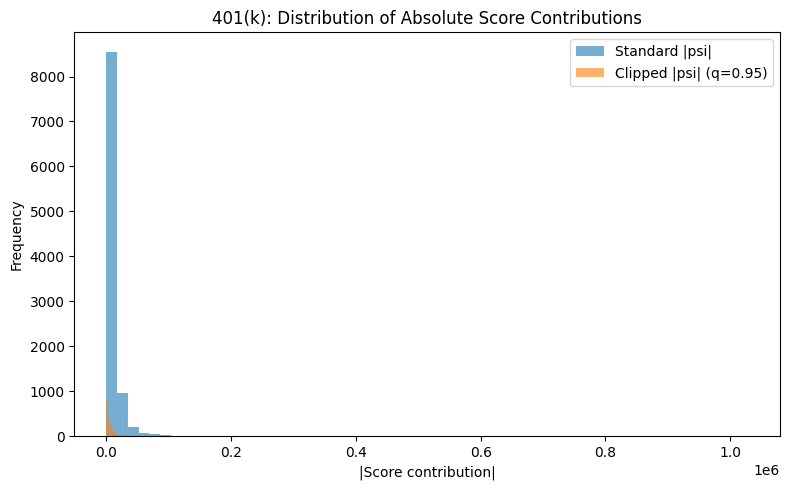

In [80]:
plt.figure(figsize=(8, 5))
plt.hist(np.abs(psi_std), bins=60, alpha=0.6, label="Standard |psi|")
plt.hist(np.abs(psi_best_clip), bins=60, alpha=0.6, label="Clipped |psi| (q=0.95)")
plt.xlabel("|Score contribution|")
plt.ylabel("Frequency")
plt.title("401(k): Distribution of Absolute Score Contributions")
plt.legend()
plt.tight_layout()
plt.savefig("results_dml_heavytail/figure_401k_abs_score_hist.png", dpi=200, bbox_inches="tight")
plt.show()

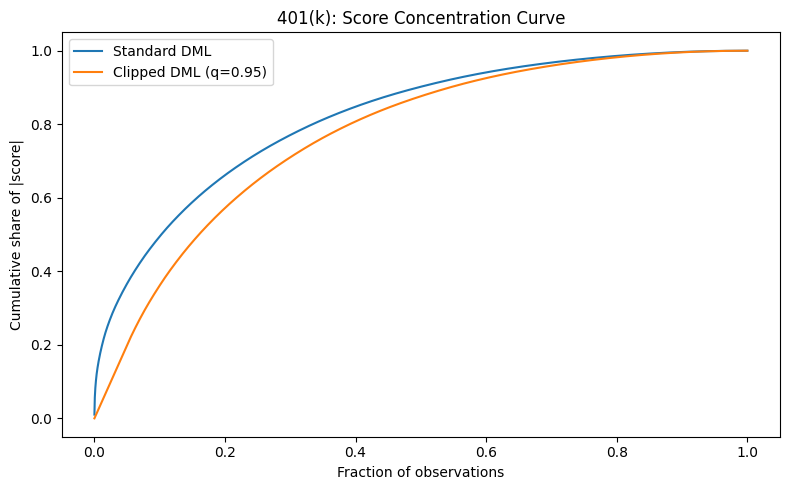

In [81]:
def cumulative_share(values: np.ndarray):
    vals = np.sort(np.abs(values))[::-1]
    cum_vals = np.cumsum(vals)
    total = cum_vals[-1]
    share_x = np.arange(1, len(vals) + 1) / len(vals)
    share_y = cum_vals / total
    return share_x, share_y

x_std, y_std = cumulative_share(psi_std)
x_clip, y_clip = cumulative_share(psi_best_clip)

plt.figure(figsize=(8, 5))
plt.plot(x_std, y_std, label="Standard DML")
plt.plot(x_clip, y_clip, label="Clipped DML (q=0.95)")
plt.xlabel("Fraction of observations")
plt.ylabel("Cumulative share of |score|")
plt.title("401(k): Score Concentration Curve")
plt.legend()
plt.tight_layout()
plt.savefig("results_dml_heavytail/figure_401k_score_concentration_curve.png", dpi=200, bbox_inches="tight")
plt.show()

In [82]:
from sklearn.metrics import mean_squared_error, log_loss, roc_auc_score

nuisance_perf_401k = {
    "g_hat_mse": float(mean_squared_error(df[Y_COL], cf_std["_g_hat"])),
    "m_hat_logloss": float(log_loss(df[D_COL], cf_std["_m_hat"], labels=[0, 1])),
    "m_hat_auc": float(roc_auc_score(df[D_COL], cf_std["_m_hat"]))
}

print(json.dumps(nuisance_perf_401k, indent=2))

{
  "g_hat_mse": 3117420419.6143665,
  "m_hat_logloss": 0.5877066777557952,
  "m_hat_auc": 0.7300928814261809
}


In [83]:
df_sim_check, x_cols_check = simulate_plr_data(
    n=simulation_design_info["n"],
    p=simulation_design_info["p"],
    theta0=simulation_design_info["theta0"],
    tail="t3",
    contamination=0.05,
    weak_overlap=True,
    nonlinear=True,
    random_state=RANDOM_STATE + 999
)

cf_sim_check = crossfit_nuisance(df_sim_check, "Y", "D", x_cols_check)

nuisance_perf_sim_hostile_example = {
    "design": "hostile example (t3, contamination=0.05, weak_overlap=True, nonlinear=True)",
    "g_hat_mse": float(mean_squared_error(df_sim_check["Y"], cf_sim_check["_g_hat"])),
    "m_hat_logloss": float(log_loss(df_sim_check["D"], cf_sim_check["_m_hat"], labels=[0, 1])),
    "m_hat_auc": float(roc_auc_score(df_sim_check["D"], cf_sim_check["_m_hat"]))
}

print(json.dumps(nuisance_perf_sim_hostile_example, indent=2))

{
  "design": "hostile example (t3, contamination=0.05, weak_overlap=True, nonlinear=True)",
  "g_hat_mse": 22.071304035481948,
  "m_hat_logloss": 0.5588249787307454,
  "m_hat_auc": 0.7860370814992663
}


In [84]:
import time

runtime_rows = []

# standard
t0 = time.perf_counter()
cf_std_rt = crossfit_nuisance(df, Y_COL, D_COL, X_COLS)
std_rt = dml_standard_from_residuals(cf_std_rt["_U_hat"].to_numpy(), cf_std_rt["_V_hat"].to_numpy(), "standard_dml")
t1 = time.perf_counter()
runtime_rows.append({"estimator": "standard_dml", "runtime_seconds": t1 - t0})

# outcome winsorized
t0 = time.perf_counter()
df_yw_rt = df.copy()
df_yw_rt[Y_COL] = winsorize_series(df_yw_rt[Y_COL], 0.01, 0.99)
cf_yw_rt = crossfit_nuisance(df_yw_rt, Y_COL, D_COL, X_COLS)
yw_rt = dml_standard_from_residuals(cf_yw_rt["_U_hat"].to_numpy(), cf_yw_rt["_V_hat"].to_numpy(), "outcome_winsorized_dml")
t1 = time.perf_counter()
runtime_rows.append({"estimator": "outcome_winsorized_dml", "runtime_seconds": t1 - t0})

# covariate winsorized
t0 = time.perf_counter()
df_xw_rt = winsorize_dataframe(df, X_COLS, 0.01, 0.99)
cf_xw_rt = crossfit_nuisance(df_xw_rt, Y_COL, D_COL, X_COLS)
xw_rt = dml_standard_from_residuals(cf_xw_rt["_U_hat"].to_numpy(), cf_xw_rt["_V_hat"].to_numpy(), "covariate_winsorized_dml")
t1 = time.perf_counter()
runtime_rows.append({"estimator": "covariate_winsorized_dml", "runtime_seconds": t1 - t0})

# clipped path
for q in [0.95, 0.97, 0.99, 0.995, 0.999]:
    t0 = time.perf_counter()
    _ = dml_clipped_from_residuals(
        cf_std_rt["_U_hat"].to_numpy(),
        cf_std_rt["_V_hat"].to_numpy(),
        q=q,
        theta_prelim=std_rt.theta
    )
    t1 = time.perf_counter()
    runtime_rows.append({"estimator": f"score_clipped_dml_q{q}", "runtime_seconds": t1 - t0})

runtime_df = pd.DataFrame(runtime_rows)
display(runtime_df)

,estimator,runtime_seconds
0,standard_dml,0.891773
1,outcome_winsorized_dml,0.977062
2,covariate_winsorized_dml,0.880492
3,score_clipped_dml_q0.95,0.016817
4,score_clipped_dml_q0.97,0.016779
5,score_clipped_dml_q0.99,0.015980
6,score_clipped_dml_q0.995,0.018901
7,score_clipped_dml_q0.999,0.020152


In [85]:
extra_bundle = {
    "simulation_design_info": simulation_design_info,
    "simulation_design_markdown": simulation_design_markdown,
    "nuisance_perf_401k": nuisance_perf_401k,
    "nuisance_perf_sim_hostile_example": nuisance_perf_sim_hostile_example,
    "runtime_records": runtime_df.to_dict(orient="records"),
    "score_distribution_summary_records": score_distribution_df.describe().reset_index().to_dict(orient="records"),
    "saved_figures": [
        "results_dml_heavytail/figure_401k_abs_score_hist.png",
        "results_dml_heavytail/figure_401k_score_concentration_curve.png"
    ]
}

with open("results_dml_heavytail/results_extra_bundle.json", "w", encoding="utf-8") as f:
    json.dump(extra_bundle, f, ensure_ascii=False, indent=2)

print("Saved: results_dml_heavytail/results_extra_bundle.json")

Saved: results_dml_heavytail/results_extra_bundle.json


In [86]:
print("=" * 100)
print("아래 내용 + 기존 결과를 보내면 ChatGPT가 새 논문 전체 작성 가능")
print("=" * 100)

print("\n## simulation_design_markdown\n")
print(simulation_design_markdown)

print("\n## nuisance_perf_401k\n")
print(json.dumps(nuisance_perf_401k, indent=2))

print("\n## nuisance_perf_sim_hostile_example\n")
print(json.dumps(nuisance_perf_sim_hostile_example, indent=2))

print("\n## runtime_markdown\n")
print(compact_table(runtime_df, list(runtime_df.columns), digits=4))

print("\n## saved_figures\n")
print("- results_dml_heavytail/figure_401k_abs_score_hist.png")
print("- results_dml_heavytail/figure_401k_score_concentration_curve.png")

print("\n추가 파일:")
print("- results_dml_heavytail/results_extra_bundle.json")

아래 내용 + 기존 결과를 보내면 ChatGPT가 새 논문 전체 작성 가능

## simulation_design_markdown


## Simulation Design

- n = 1500
- p = 10
- theta0 = 0.5
- Tail distributions = ['normal', 't5', 't3']
- Contamination grid = [0.0, 0.05]
- Overlap grid = {'False': 'strong overlap', 'True': 'weak overlap'}
- Weak overlap implementation = m_latent is multiplied by 2.0 before the logistic link
- Nonlinear grid = {'False': 'linear nuisance', 'True': 'nonlinear nuisance'}
- Contamination implementation = For a contamination share c, Y_i receives an additive shock N(20, 5^2) for randomly selected contaminated observations.
- Outcome learner = Pipeline(StandardScaler + LassoCV(cv=5, n_alphas=50, max_iter=20000))
- Treatment learner = Pipeline(StandardScaler + LogisticRegressionCV(cv=5, penalty='l2', solver='lbfgs', scoring='neg_log_loss', max_iter=5000))
- Cross-fitting folds = 5
- Simulation reps = 20
- Clipping grid = [0.95, 0.97, 0.99, 0.995, 0.999]
- Winsorization quantiles = [0.01, 0.99]
- Random state = 2026032